# 04 注意力机制与 Transformer

本 Notebook 覆盖：
- Scaled Dot-Product Attention 手动实现
- 注意力权重热力图可视化
- 多头注意力实现
- 完整 Transformer Block

**对应文档**: `docs/04-attention-transformer/`

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
import numpy as np

device = torch.device(
    'mps'  if torch.backends.mps.is_available() else
    'cuda' if torch.cuda.is_available() else 'cpu'
)
print(f'使用设备: {device}')

使用设备: cpu


## 1. Scaled Dot-Product Attention

In [2]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """Q,K,V: (batch, seq, d_k)"""
    d_k    = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))
    attn = F.softmax(scores, dim=-1)
    return torch.matmul(attn, V), attn


# 模拟句子: "我 爱 深度 学习"
seq_len, d_k = 4, 8
torch.manual_seed(0)
Q = torch.randn(1, seq_len, d_k)
K = torch.randn(1, seq_len, d_k)
V = torch.randn(1, seq_len, d_k)

output, attn_weights = scaled_dot_product_attention(Q, K, V)
print(f'输出 shape: {output.shape}')
print(f'注意力权重 shape: {attn_weights.shape}')
print(f'每行权重之和: {attn_weights[0].sum(dim=-1)}')

输出 shape: torch.Size([1, 4, 8])
注意力权重 shape: torch.Size([1, 4, 4])
每行权重之和: tensor([1.0000, 1.0000, 1.0000, 1.0000])


## 2. 注意力权重热力图

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16400\1169629324.py:23: UserWarning: Glyph 25105 (\N{CJK UNIFIED IDEOGRAPH-6211}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_16400\1169629324.py:23: UserWarning: Glyph 29233 (\N{CJK UNIFIED IDEOGRAPH-7231}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_16400\1169629324.py:23: UserWarning: Glyph 28145 (\N{CJK UNIFIED IDEOGRAPH-6DF1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_16400\1169629324.py:23: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_16400\1169629324.py:23: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_164

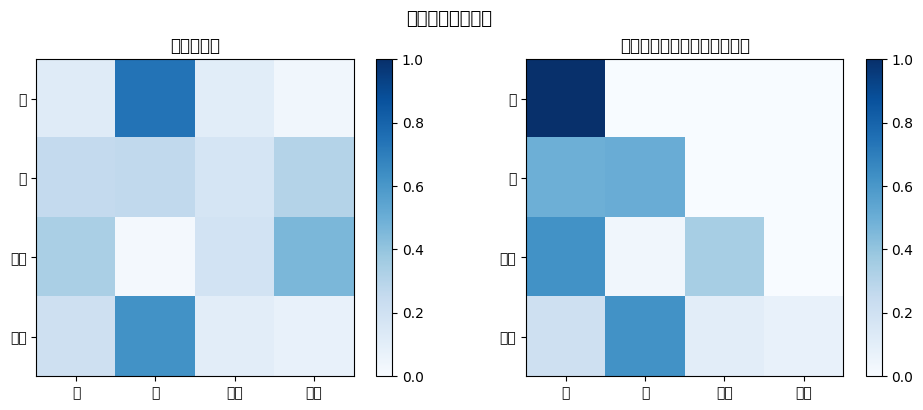

In [4]:
tokens = ['我', '爱', '深度', '学习']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 无掩码的注意力
_, w_full = scaled_dot_product_attention(Q, K, V)
im0 = axes[0].imshow(w_full[0].detach().numpy(), cmap='Blues', vmin=0, vmax=1)
axes[0].set_xticks(range(seq_len)); axes[0].set_xticklabels(tokens)
axes[0].set_yticks(range(seq_len)); axes[0].set_yticklabels(tokens)
axes[0].set_title('全局注意力')
plt.colorbar(im0, ax=axes[0])

# 带因果掩码的注意力
causal_mask = torch.tril(torch.ones(seq_len, seq_len))
_, w_causal = scaled_dot_product_attention(Q, K, V, mask=causal_mask)
im1 = axes[1].imshow(w_causal[0].detach().numpy(), cmap='Blues', vmin=0, vmax=1)
axes[1].set_xticks(range(seq_len)); axes[1].set_xticklabels(tokens)
axes[1].set_yticks(range(seq_len)); axes[1].set_yticklabels(tokens)
axes[1].set_title('因果掩码注意力（语言模型）')
plt.colorbar(im1, ax=axes[1])

plt.suptitle('注意力权重热力图', fontsize=13)
plt.tight_layout()
plt.show()

## 3. 多头注意力实现

In [5]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k     = d_model // n_heads
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x):
        B, S, _ = x.shape
        return x.view(B, S, self.n_heads, self.d_k).transpose(1, 2)

    def forward(self, x, mask=None):
        B, S, _ = x.shape
        Q = self.split_heads(self.W_q(x))
        K = self.split_heads(self.W_k(x))
        V = self.split_heads(self.W_v(x))
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        attn = self.dropout(F.softmax(scores, dim=-1))
        out  = torch.matmul(attn, V)
        out  = out.transpose(1, 2).contiguous().view(B, S, self.d_model)
        return self.W_o(out), attn


d_model, n_heads = 64, 8
mha = MultiHeadAttention(d_model, n_heads).to(device)
x   = torch.randn(2, 10, d_model).to(device)
out, attn = mha(x)

print(f'输入 shape:     {x.shape}')
print(f'输出 shape:     {out.shape}')
print(f'注意力 shape:   {attn.shape}  (batch, heads, seq, seq)')

输入 shape:     torch.Size([2, 10, 64])
输出 shape:     torch.Size([2, 10, 64])
注意力 shape:   torch.Size([2, 8, 10, 10])  (batch, heads, seq, seq)


## 4. 多头注意力权重可视化

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16400\2195099937.py:11: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_16400\2195099937.py:11: UserWarning: Glyph 27880 (\N{CJK UNIFIED IDEOGRAPH-6CE8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_16400\2195099937.py:11: UserWarning: Glyph 24847 (\N{CJK UNIFIED IDEOGRAPH-610F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_16400\2195099937.py:11: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_16400\2195099937.py:11: UserWarning: Glyph 22836 (\N{CJK UNIFIED IDEOGRAPH-5934}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_164

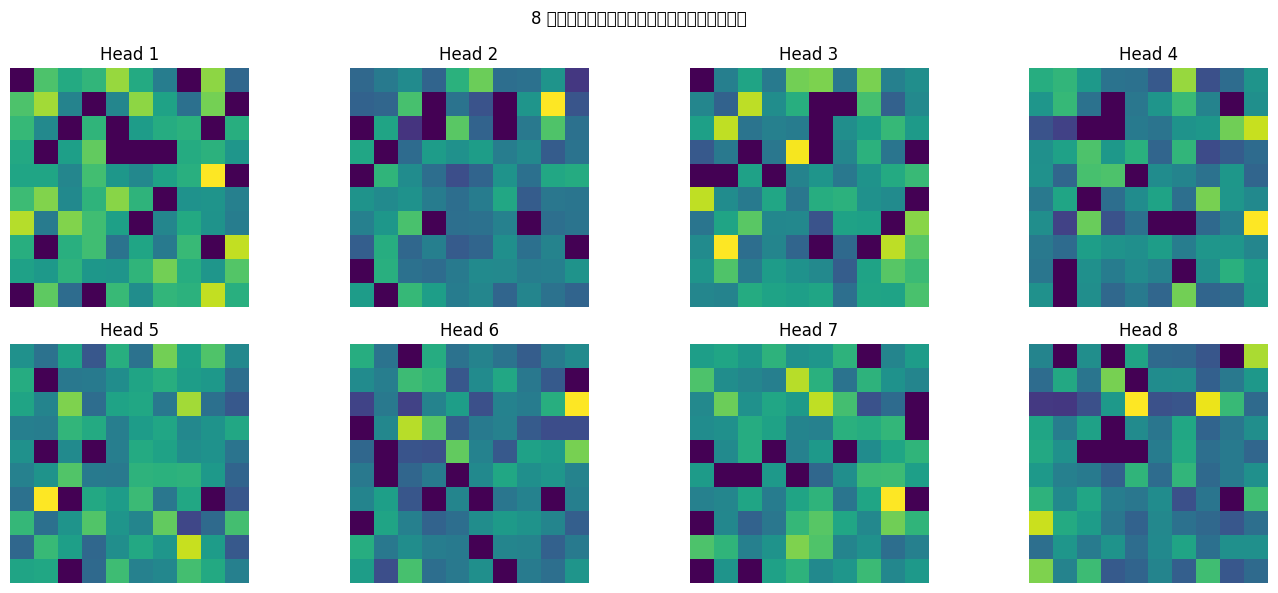

In [6]:
# 可视化 8 个注意力头的权重分布
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
attn_np = attn[0].detach().cpu().numpy()  # (heads, seq, seq)

for h, ax in enumerate(axes.flatten()):
    im = ax.imshow(attn_np[h], cmap='viridis', vmin=0, vmax=attn_np[h].max())
    ax.set_title(f'Head {h+1}')
    ax.axis('off')

plt.suptitle('8 个注意力头的权重分布（各头关注不同位置）', fontsize=12)
plt.tight_layout()
plt.show()

## 5. 完整 Transformer Block

In [7]:
class TransformerBlock(nn.Module):
    """Pre-LN Transformer Block"""
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn    = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ff      = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout),
        )
        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # 自注意力 + 残差
        attn_out, _ = self.attn(self.norm1(x), self.norm1(x), self.norm1(x),
                                attn_mask=mask)
        x = x + self.dropout(attn_out)
        # 前馈 + 残差
        x = x + self.ff(self.norm2(x))
        return x


block = TransformerBlock(d_model=64, n_heads=8, d_ff=256).to(device)
x_in  = torch.randn(2, 10, 64).to(device)
x_out = block(x_in)

print(f'输入 shape:  {x_in.shape}')
print(f'输出 shape:  {x_out.shape}  (形状不变，这是 Transformer 的关键特性)')
print(f'参数量: {sum(p.numel() for p in block.parameters()):,}')

输入 shape:  torch.Size([2, 10, 64])
输出 shape:  torch.Size([2, 10, 64])  (形状不变，这是 Transformer 的关键特性)
参数量: 49,984


## 练习题

1. **简单**: 修改 `MultiHeadAttention`，使 `n_heads=1`，验证它退化为单头注意力
2. **中等**: 实现 Cross-Attention（Q 来自 decoder，K/V 来自 encoder），用于 Seq2Seq 场景
3. **挑战**: 堆叠 4 个 `TransformerBlock` 构成编码器，在 SST-2 情感分类数据集上微调并评估准确率